### Import Librairies

In [142]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
sns.set_theme(style='whitegrid', context='notebook')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import data

In [143]:
data_matrix = pd.read_csv('data/input/internship_data_matrix.csv', index_col=0)
features = pd.read_csv('data/input/internship_feature_metadata.csv', index_col=0)
acquisition = pd.read_csv('data/input/intership_acquisition_list.csv', index_col=0)
exogenous = pd.read_csv('data/input/exogenous_standards.csv', index_col=0)

### Check the data

In [4]:
data_matrix

,FT-000,FT-001,FT-002,FT-003,FT-004,FT-005,FT-006,FT-007,FT-008,FT-009,...,FT-242,FT-243,FT-244,FT-245,FT-246,FT-247,FT-248,FT-249,FT-250,FT-251
sample,,,,,,,,,,,,,,,,,,,,,
20241106-297-Blank1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
20241106-297-Blank2,0.000000,0.000000,0.000000,5.770641,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,3.534493,0.0,0.000000,0.0
20241106-297-Blank3,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,6.469501,0.0,0.000000,0.0
20241106-297-Blank4,0.000000,5.497865,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
20241106-297-Blank5,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20241113-300-QC5,996.209869,720.286706,38.881401,2208.747760,0.000000,0.0,0.0,50.556588,17.328638,0.0,...,15.607478,13.100865,0.000000,5.905703,0.0,0.000000,113.023747,0.0,17.745493,0.0
20241113-300-QC6,1942.895671,2764.681073,25.908065,4870.323716,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,4.972839,5.864162,0.000000,5.864162,0.0,0.000000,114.471351,0.0,2.489453,0.0
20241113-300-QC7,269.836511,153.647364,27.933945,694.930709,0.000000,0.0,0.0,39.657529,0.000000,0.0,...,4.222424,6.319850,0.000000,0.000000,0.0,4.160818,86.823600,0.0,0.000000,0.0


In [5]:
features

,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
feature,,,,,,,,,,
FT-000,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
FT-001,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
FT-002,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
FT-003,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
FT-004,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684
...,...,...,...,...,...,...,...,...,...,...
FT-247,1210.823728,1210.891724,1210.766982,0.035176,886.037193,894.114049,889.331356,883.543251,881.398350,1.336007
FT-248,925.136196,925.183723,925.091923,0.024345,1057.851741,1064.927980,1060.490508,1055.485902,1046.123490,1.362119
FT-249,1069.709184,1069.780424,1069.644986,0.032195,1158.068152,1163.637293,1160.474373,1155.226101,1149.945018,1.242633


In [6]:
acquisition

,class,id,order,batch
sample,,,,
20241106-297-Blank1,B,20241106-297-Blank1,1,1
20241106-297-Blank2,B,20241106-297-Blank2,2,1
20241106-297-Blank3,B,20241106-297-Blank3,3,1
20241106-297-Blank4,B,20241106-297-Blank4,102,1
20241106-297-Blank5,B,20241106-297-Blank5,103,1
...,...,...,...,...
20241113-300-QC5,QC,20241113-300-QC5,117,2
20241113-300-QC6,QC,20241113-300-QC6,118,2
20241113-300-QC7,QC,20241113-300-QC7,119,2


In [7]:
exogenous

,mz,Retention_time
compound_id,,
GU4,886.40,610
GU5,1048.45,753
GU14,1253.96,1500
GU15,1334.99,1551


What classes so we have?

In [8]:
acquisition['class'].unique()

<ArrowStringArray>
['B', 'dQC', 'Dunn', 'SS', 'French', 'LMU', 'QC']
Length: 7, dtype: str

Check if there are any NaN values

In [49]:
print(data_matrix.isna().sum().sum())
print(features.isna().sum().sum())
print(acquisition.isna().sum().sum())
print(exogenous.isna().sum().sum())

0
0
0
0


Check if there are duplicate samples in the data matrix

In [50]:
if len(set(data_matrix.index)) == len(data_matrix):
    print("No duplicate samples in data matrix.")
else:
    print("Duplicate samples found in data matrix.")

No duplicate samples in data matrix.


Check if there are duplicate samples in acquisition

In [10]:
if len(set(acquisition.index)) == len(acquisition):
    print("No duplicate samples in acquisition.")
else:
    print("Duplicate samples found in acquisition.")

No duplicate samples in acquisition.


Check if the samples in data matrix and acquisition match

In [11]:
if set(data_matrix.index) == set(acquisition.index):
    print("Data matrix and acquisition samples match.")
else:
    print("Data matrix and acquisition samples do not match.")

Data matrix and acquisition samples match.


Check if the data matrix features and features metadata match

In [12]:
if set(data_matrix.columns) == set(features.index):
    print("Data matrix features and feature metadata match.")
else:
    print("Data matrix features and feature metadata do not match.")

Data matrix features and feature metadata match.


Quick profile check (shapes, column names, class counts per batch)

In [51]:
print('data_matrix shape:', data_matrix.shape)
print('features shape:', features.shape)
print('acquisition shape:', acquisition.shape)
print('exogenous shape:', exogenous.shape)

print('\nfeature columns:', features.columns.tolist())
print('acquisition columns:', acquisition.columns.tolist())
print('exogenous columns:', exogenous.columns.tolist())

print('\nclass counts:')
print(acquisition['class'].value_counts(dropna=False))

print('\nbatch x class:')
print(pd.crosstab(acquisition['batch'], acquisition['class']))

data_matrix shape: (124, 252)
features shape: (252, 10)
acquisition shape: (124, 4)
exogenous shape: (4, 2)

feature columns: ['mz', 'mz max', 'mz min', 'mz std', 'rt', 'rt end', 'rt max', 'rt min', 'rt start', 'rt std']
acquisition columns: ['class', 'id', 'order', 'batch']
exogenous columns: ['mz', 'Retention_time']

class counts:
class
Dunn      27
French    26
LMU       26
QC        22
B         11
dQC       10
SS         2
Name: count, dtype: int64

batch x class:
class  B  Dunn  French  LMU  QC  SS  dQC
batch                                   
1      6    27      26   26  11   1    5
2      5     0       0    0  11   1    5


### Harmonize metadata and define class and batch masks

In [144]:
acq = acquisition.copy()
acq['class'] = acq['class'].replace({'dQC': 'QC'})

X = data_matrix.loc[acq.index].copy()
feat = features.loc[X.columns].copy()

batch1_mask = acq['batch'] == 1
bio_classes = ['French', 'LMU', 'Dunn']

batch1_acq = acq.loc[batch1_mask].copy()
batch1_X = X.loc[batch1_mask].copy()

bio_mask_b1 = batch1_acq['class'].isin(bio_classes)
qc_mask_b1 = batch1_acq['class'].eq('QC')
blank_mask_b1 = batch1_acq['class'].eq('B')
ss_mask_all = acq['class'].eq('SS')

### Detection threshold and feature detection rates

In order to filter background noise from true molecular signal, we define a threshold of minimal intensity to consider a peak detected. We use the 5th percentile of non-zero peak areas, therefore avoiding arbitrary cutoffs and adapting to the empirical distribution of the signal.

In [138]:
nonzero = X.values[X.values > 0]
detection_threshold = float(np.quantile(nonzero, 0.05))
print(f'Detection threshold (5th percentile of non-zero areas): {detection_threshold:,.2f}')

is_detected = X >= detection_threshold
overall_detection_rate = is_detected.mean(axis=0)
print('Feature detection summary (overall):')
print(overall_detection_rate.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

Detection threshold (5th percentile of non-zero areas): 31.99
Feature detection summary (overall):
count    252.000000
mean       0.762801
std        0.068997
min        0.233871
10%        0.741935
25%        0.766129
50%        0.766129
75%        0.774194
90%        0.798387
max        0.943548
dtype: float64


Most features are consistently detected (overall detection rate centered around $\sim0.76$).

Let's visualize the feature detection rate by m/z and RT, and its overall distribution

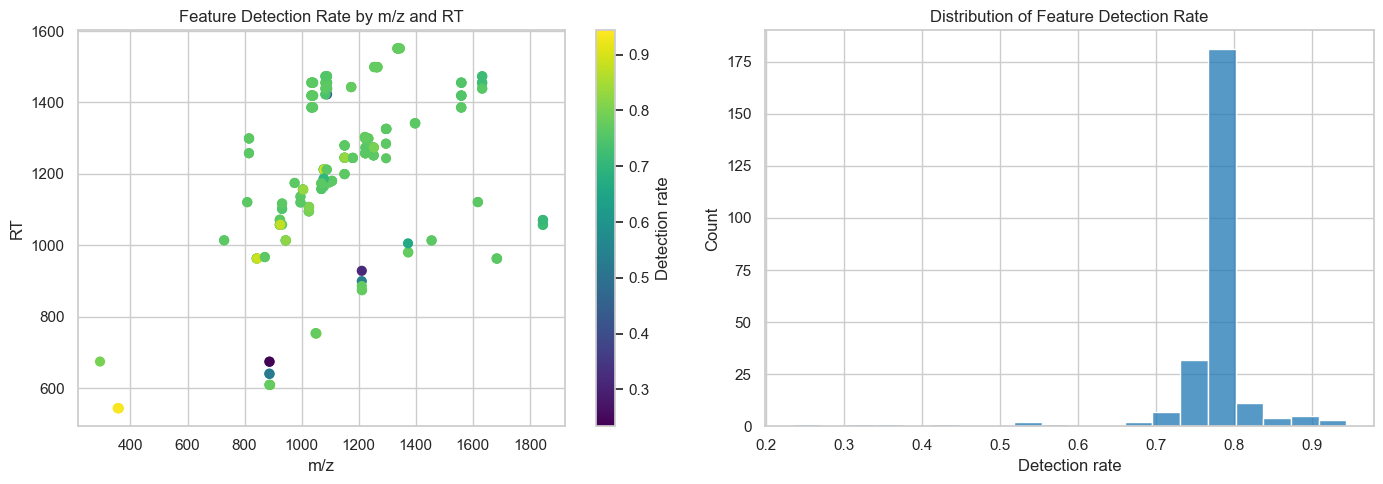

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(feat['mz'], feat['rt'], c=overall_detection_rate, cmap='viridis', s=40)
axes[0].set_title('Feature Detection Rate by m/z and RT')
axes[0].set_xlabel('m/z')
axes[0].set_ylabel('RT')
plt.colorbar(sc, ax=axes[0], label='Detection rate')

sns.histplot(overall_detection_rate, bins=20, ax=axes[1], color='#1f77b4')
axes[1].set_title('Distribution of Feature Detection Rate')
axes[1].set_xlabel('Detection rate')
plt.tight_layout()
plt.show()

Let's check the feature detection rates per class. We'll focus on batch 1 since it has all classes.

In [59]:
class_detection = {}
for cls in ['French', 'LMU', 'Dunn', 'QC', 'B', 'SS']:
    mask = (batch1_acq['class'] == cls)
    if mask.sum() > 0:
        class_detection[cls] = (batch1_X.loc[mask] >= detection_threshold).mean(axis=0)
class_detection = pd.DataFrame(class_detection)

In [63]:
class_detection.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

,count,mean,std,min,10%,25%,50%,75%,90%,max
French,252.0,0.991453,0.049010,0.461538,1.000000,1.0,1.0,1.0,1.0,1.0
LMU,252.0,0.969475,0.133041,0.000000,0.961538,1.0,1.0,1.0,1.0,1.0
Dunn,252.0,0.983245,0.102660,0.000000,0.966667,1.0,1.0,1.0,1.0,1.0
QC,252.0,0.979663,0.084547,0.187500,0.937500,1.0,1.0,1.0,1.0,1.0
B,252.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
SS,252.0,0.178571,0.383755,0.000000,0.000000,0.0,0.0,0.0,1.0,1.0


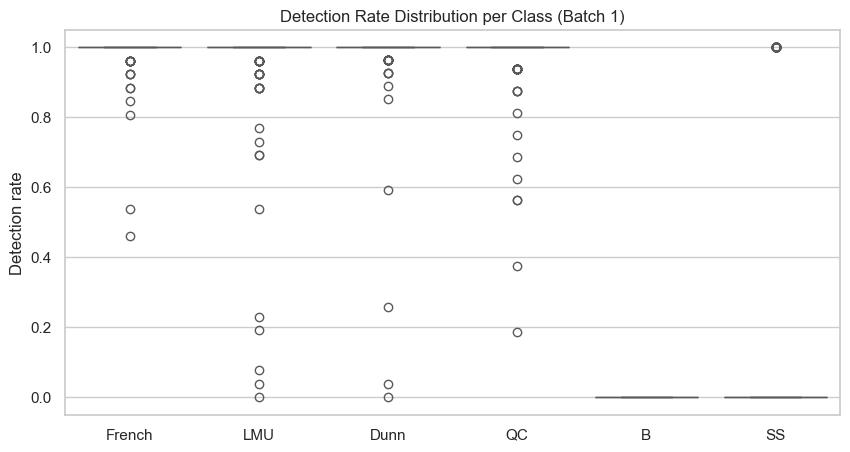

In [60]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=class_detection, palette='Set2')
plt.title('Detection Rate Distribution per Class (Batch 1)')
plt.ylabel('Detection rate')
plt.show()

- In batch 1, detection rates are consistently high across biological and QC samples, while blanks show no detectable signal, indicating low contamination.

- Biological samples exhibit near-complete detection rates, with medians equal to 1.0 across all classes, indicating that the majority of feature.s are consistently observed across individuals. A small number of outliers with reduced detection may reflect sample-specific quality issues.

- Pooled QC samples show consistently high detection rates, supporting the reproducibility of the analytical platform, although a few lower-detection outliers suggest minor technical variability during the acquisition.

- Blank samples show zero detection across all features, indicating the absence of measurable contamination and confirming that detected signals in biological samples are unlikely to arise from background artifacts.

- Detection rate analysis reveals that both biological and QC samples exhibit near-complete feature detection, indicating strong analytical sensitivity and consistent measurement across samples. The absence of detected features in blank samples confirms minimal contamination, supporting the reliability of the dataset. Overall, the data demonstrates high quality and is well-suited for downstream biomarker discovery, with only minor variability observed in a subset of biological samples.

### Isomers and Isotopes/Adducts detection and correlation

Let's check if there are features that could correspond to isomers (same mass but diffrent retention time) and if there are features that could correspond to isotopes or adducts (same retention time but different mass).

We will suppose that two features $f_i$ and $f_j$ have the same $m/z$ if $|m/z_i - m/z_j|\leq \min(\sigma_{m/z_i},\sigma_{m/z_j})/3$, and different $m/z$ if $|m/z_i - m/z_j|\geq 3\max(\sigma_{m/z_i},\sigma_{m/z_j})$.

Same thing for $RT$, same $RT$ if $|RT_i - RT_j|\leq \min(\sigma_{RT_i},\sigma_{RT_j})/3$ and different $RT$ if $|RT_i - RT_j|\geq 3\max(\sigma_{RT_i},\sigma_{RT_j})$

In [137]:
feature_ids = feat.index.to_list()
pairs = []


for i in range(len(feature_ids)):
    fi = feature_ids[i]
    mz_i, rt_i, mz_std_i, rt_std_i = feat.loc[fi, ['mz', 'rt', 'mz std', 'rt std']]
    for j in range(i + 1, len(feature_ids)):
        fj = feature_ids[j]
        mz_j, rt_j, mz_std_j, rt_std_j = feat.loc[fj, ['mz', 'rt', 'mz std', 'rt std']]
        dmz = abs(mz_i - mz_j)
        drt = abs(rt_i - rt_j)

        if dmz <= min(mz_std_i, mz_std_j)/3 and drt >= max(rt_std_i, rt_std_j)*3:
            # different RT, similar mass -> isomer-like candidate space
            pairs.append((fi, fj, 'isomer_like', dmz, drt))
        elif drt <= min(rt_std_i, rt_std_j)/3 and dmz >= max(mz_std_i, mz_std_j)*3:
            # same RT, different mass -> isotope/adduct-like candidate space
            pairs.append((fi, fj, 'isotope_adduct_like', dmz, drt))

pair_df = pd.DataFrame(pairs, columns=['f1', 'f2', 'pair_type', 'delta_mz', 'delta_rt'])
print('Pair candidate counts:')
print(pair_df['pair_type'].value_counts())

Pair candidate counts:
pair_type
isotope_adduct_like    676
isomer_like            127
Name: count, dtype: int64


Let's check correlation among candidate pairs

In [136]:
X_corr = np.log1p(batch1_X.loc[batch1_acq['class'].isin(bio_classes + ['QC'])])

corr_rows = []
for _, row in pair_df.iterrows():
    a, b = row['f1'], row['f2']
    x = X_corr[a]
    y = X_corr[b]
    valid = x.notna() & y.notna()
    if valid.sum() >= 8:
        r, p = pearsonr(x[valid], y[valid])
        corr_rows.append((a, b, row['pair_type'], row['delta_mz'], row['delta_rt'], r, p))

corr_df = pd.DataFrame(corr_rows, columns=['f1', 'f2', 'pair_type', 'delta_mz', 'delta_rt', 'pearson_r', 'pval'])
print('Correlation summary by pair type:')
if len(corr_df) > 0:
    print(corr_df.groupby('pair_type')['pearson_r'].describe())
else:
    print('No pair correlations could be computed with current thresholds.')


Correlation summary by pair type:
                     count      mean       std       min       25%       50%  \
pair_type                                                                      
isomer_like          127.0  0.556741  0.304319 -0.283241  0.324808  0.665081   
isotope_adduct_like  676.0  0.577120  0.347767 -0.160141  0.270067  0.623870   

                          75%       max  
pair_type                                
isomer_like          0.802448  0.979344  
isotope_adduct_like  0.932264  0.998932  


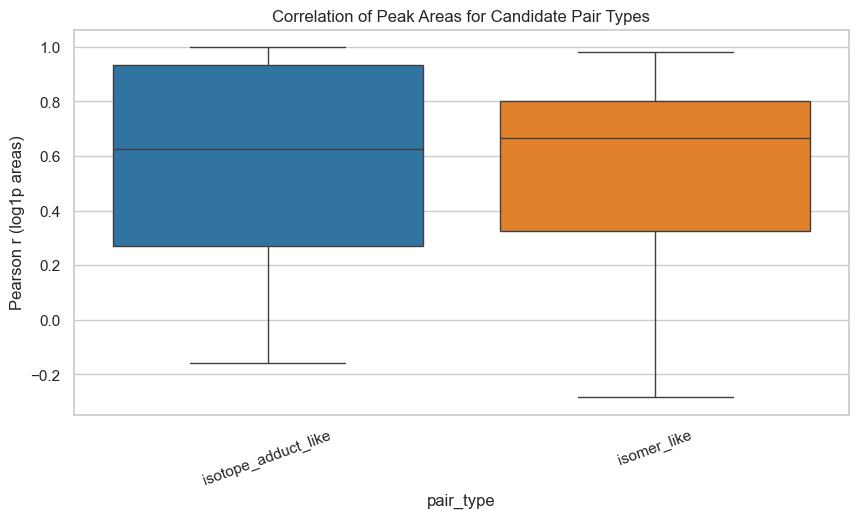

In [108]:
if len(corr_df) > 0:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=corr_df, x='pair_type', y='pearson_r', palette='tab10', hue='pair_type', legend=False)
    plt.xticks(rotation=20)
    plt.title('Correlation of Peak Areas for Candidate Pair Types')
    plt.ylabel('Pearson r (log1p areas)')
    plt.show()

Both pair types show moderate to high correlation in peak areas. I don't know what is physically expected, but we could use the physical expectation of correlation to filter out false positives, especially if the tolerance that I've set (3*std and std/3) are too loose.

### Coefficient of variation (CV) and D-Ratio

- Pooled QC is a mixture of all biological samples. It represents an "average of the dataset". So the biological variation is very low, therefore any significant variation would correspond to technical variation (i.e, instrument noise). Therefore we compute its coefficient of variation $CV=\frac{\text{std}}{\text{mean}}$. Good quality measurements would correspond to low $CV$ on QC samples.

- Biological samples (French, LMU, Dunn) are the real patient samples. These samples should contain biological variation (real differences between patients) and low technical variation (measurement noise). The technical variation is measured by the std of QC samples and biological variation is measured by the std of biological samples. So we compute the D-ratio defined by: $\text{D-ratio}=\frac{\text{std}_{QC}}{\text{std}_{\text{biological}}}$. Low D-ratio -> good data.

In [110]:
X_b1_log = np.log1p(batch1_X)
qc_vals = X_b1_log.loc[qc_mask_b1]
bio_vals = X_b1_log.loc[bio_mask_b1]

qc_mean = qc_vals.mean(axis=0)
qc_std = qc_vals.std(axis=0, ddof=1)
qc_cv = 100 * qc_std / (qc_mean.replace(0, np.nan))

bio_var = bio_vals.var(axis=0, ddof=1)
qc_var = qc_vals.var(axis=0, ddof=1)

d_ratio = 100 * np.sqrt(qc_var / (bio_var + 1e-12))

var_df = pd.DataFrame({
    'qc_cv_pct': qc_cv,
    'd_ratio_pct': d_ratio,
    'detection_rate_batch1': (batch1_X >= detection_threshold).mean(axis=0),
    'mz': feat['mz'],
    'rt': feat['rt']
})

In [135]:
print('QC CV and D-ratio summary:')
print(var_df[['qc_cv_pct', 'd_ratio_pct']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
print(f"Features with QC CV < 30%: {(var_df['qc_cv_pct'] < 30).sum()} / {len(var_df)}")
print(f"Features with D-ratio < 50%: {(var_df['d_ratio_pct'] < 50).sum()} / {len(var_df)}")

QC CV and D-ratio summary:
        qc_cv_pct  d_ratio_pct
count  252.000000   252.000000
mean     7.280522   129.051454
std     10.259625    43.468510
min      1.039800    32.090075
10%      2.153534    75.409717
25%      3.183878    98.346144
50%      4.281344   126.027634
75%      6.876338   163.078398
90%     14.043750   180.127985
max     73.446673   323.036448
Features with QC CV < 30%: 244 / 252
Features with D-ratio < 50%: 8 / 252


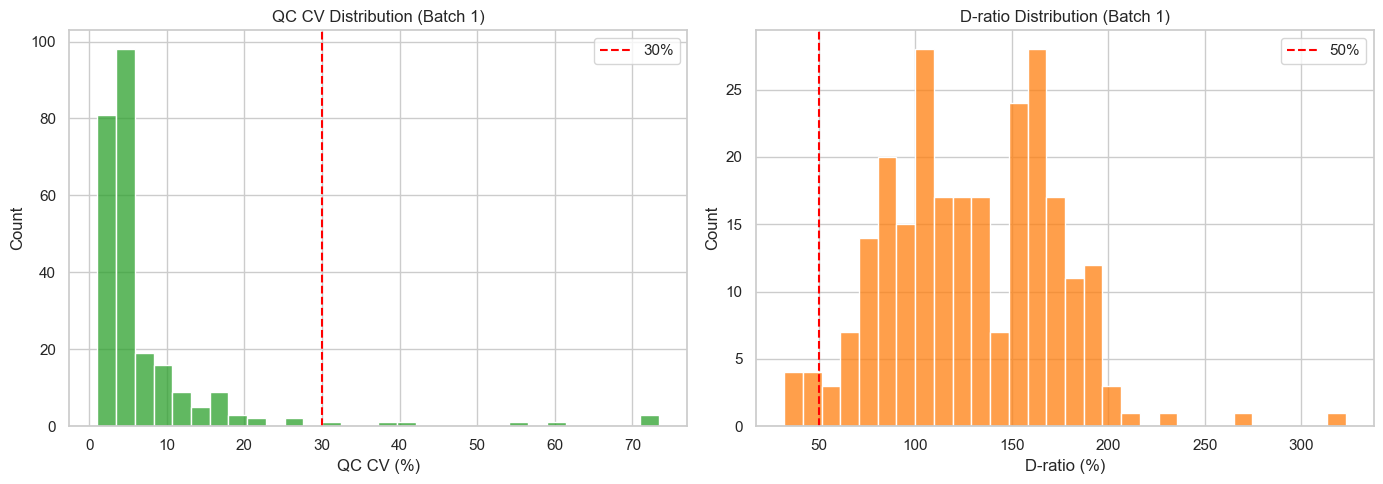

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(var_df['qc_cv_pct'].replace([np.inf, -np.inf], np.nan).dropna(), bins=30, ax=axes[0], color='#2ca02c')
axes[0].axvline(30, color='red', linestyle='--', label='30%')
axes[0].set_title('QC CV Distribution (Batch 1)')
axes[0].set_xlabel('QC CV (%)')
axes[0].legend()

sns.histplot(var_df['d_ratio_pct'].replace([np.inf, -np.inf], np.nan).dropna(), bins=30, ax=axes[1], color='#ff7f0e')
axes[1].axvline(50, color='red', linestyle='--', label='50%')
axes[1].set_title('D-ratio Distribution (Batch 1)')
axes[1].set_xlabel('D-ratio (%)')
axes[1].legend()
plt.tight_layout()
plt.show()

- QC reproducibility in batch 1 is strong: 244/252 features have QC CV < 30%.
- D-ratio is high for many features (median > 100% with this implementation), suggesting technical variation may still dominate for a substantial part of the panel without additional normalization/filtering.
- The run is exploitable for discovery in batch 1, but feature filtering and normalization are required before differential testing.

### Contamination profile using blanks

We saw earlier that all blank samples have 0 detection rate, so there were no contamination-like features. In the future, in case we have non-zero detection rate in blank samples, we could mitigate contamination effect by computing, for each feature, the median peak area of blank samples and the median for the biological samples and compute the ratio of the medians (blank/biological). And then we exclude the features that have a high ratio.

### Exogenous standards tracking (SS consistency)

In [115]:
standards = exogenous.rename(columns={'Retention_time': 'rt'})[['mz', 'rt']].copy()

In [116]:
# Match each standard to nearest detected feature in mz/rt space
match_rows = []
for std_name, row in standards.iterrows():
    dmz = (feat['mz'] - row['mz']).abs()
    drt = (feat['rt'] - row['rt']).abs()
    score = dmz / feat["mz std"] + drt / feat["rt std"] # weight by precision. 
    best_feature = score.idxmin()
    match_rows.append((std_name, best_feature, dmz.loc[best_feature], drt.loc[best_feature]))

std_map = pd.DataFrame(match_rows, columns=['standard', 'matched_feature', 'delta_mz', 'delta_rt'])

In [134]:
print('Standard-to-feature matching:')
print(std_map)

Standard-to-feature matching:
  standard matched_feature  delta_mz  delta_rt
0      GU4          FT-005  0.232460  0.538711
1      GU5          FT-010  0.274800  0.824614
2     GU14          FT-162  0.317029  0.595175
3     GU15          FT-169  0.333637  0.257112


In [118]:
# Evaluate matched standards across run order
std_signal = pd.DataFrame(index=acq.index)
for _, row in std_map.iterrows():
    std_signal[row['standard']] = X[row['matched_feature']]

std_signal = std_signal.join(acq[['order', 'batch', 'class']])

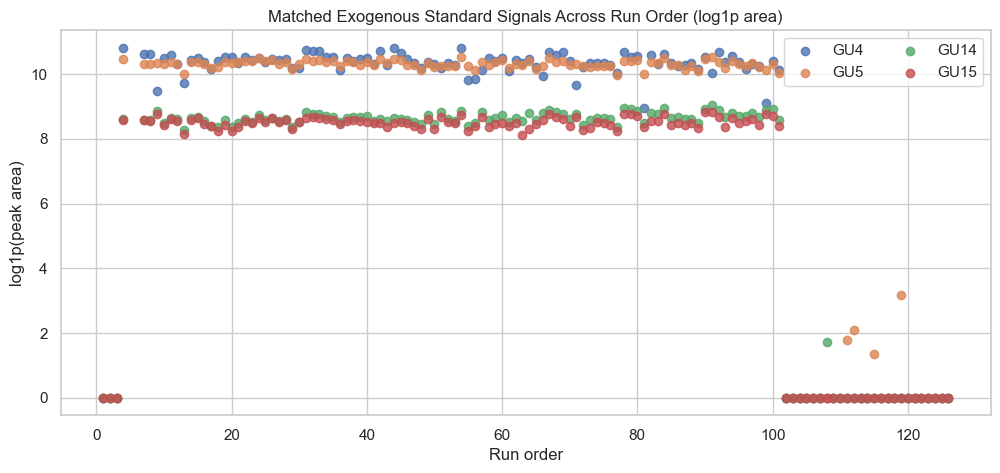

In [123]:
plt.figure(figsize=(12, 5))
for std in standards.index:
    vals = np.log1p(std_signal[std])
    plt.scatter(std_signal['order'], vals, marker='o', linewidth=1, alpha=0.8, label=std)
plt.title('Matched Exogenous Standard Signals Across Run Order (log1p area)')
plt.xlabel('Run order')
plt.ylabel('log1p(peak area)')
plt.legend(ncol=2)
plt.show()

In [133]:
print('SS-only summary for matched standards (log1p):')
ss_vals = std_signal.loc[ss_mask_all, standards.index].apply(np.log1p)
print(ss_vals.describe().T[['mean', 'std', 'min', 'max']])

SS-only summary for matched standards (log1p):
                 mean       std  min        max
compound_id                                    
GU4          5.406288  7.645646  0.0  10.812577
GU5          5.237194  7.406511  0.0  10.474388
GU14         4.309858  6.095060  0.0   8.619716
GU15         4.295870  6.075278  0.0   8.591740


- Standards can be mapped to nearest detected features, but non-negligible m/z offsets suggest they are approximated rather than exact one-to-one IDs in this feature table.
- Signal trajectories indicate clear batch dependence (strong signal during batch 1, near-zero in later runs), so standards should be used as calibration anchors within batch rather than across-batch absolute comparators.

### Intensity distribution by class and run-order drift

In [125]:
total_intensity = X.sum(axis=1)
log_total_intensity = np.log1p(total_intensity)

sample_summary = acq.copy()
sample_summary['total_intensity'] = total_intensity
sample_summary['log_total_intensity'] = log_total_intensity

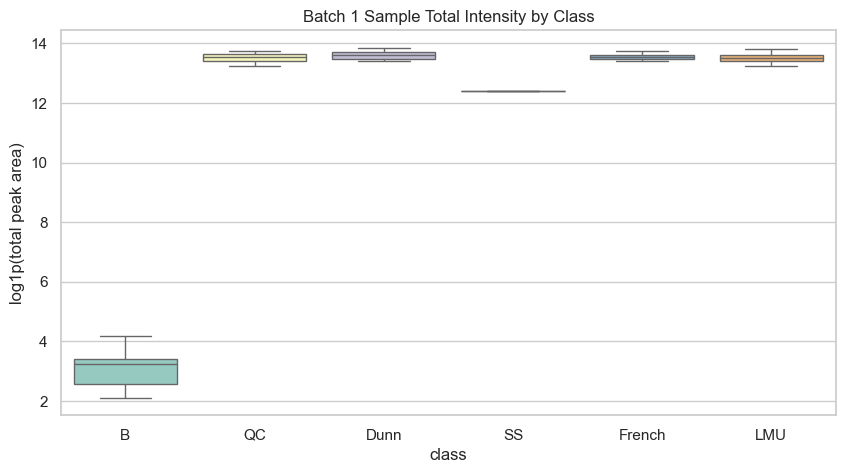

In [126]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=sample_summary.loc[batch1_mask], x='class', y='log_total_intensity', palette='Set3', hue='class', legend=False)
plt.title('Batch 1 Sample Total Intensity by Class')
plt.ylabel('log1p(total peak area)')
plt.show()

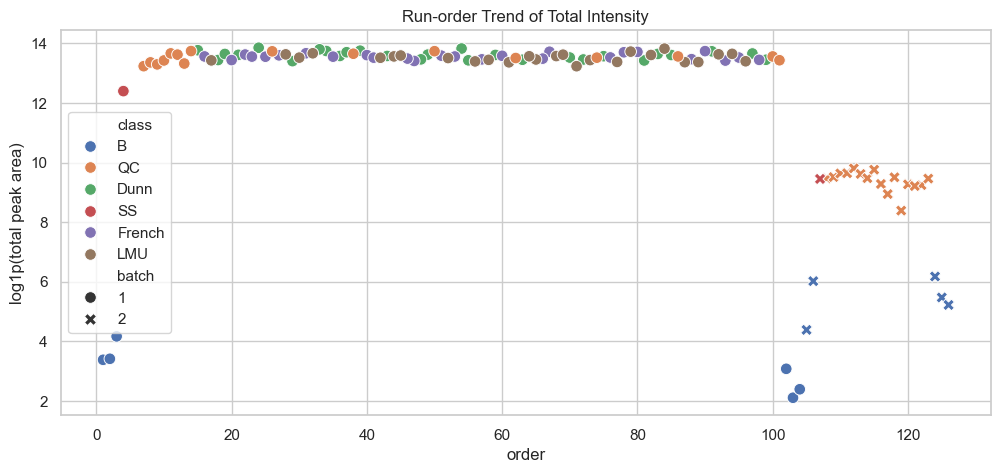

In [127]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=sample_summary, x='order', y='log_total_intensity', hue='class', style='batch', s=70)
plt.title('Run-order Trend of Total Intensity')
plt.ylabel('log1p(total peak area)')
plt.show()

- Batch 1 classes (`French`, `LMU`, `Dunn`, `QC`) have similar total-intensity distributions, consistent with stable acquisition.
- Batch 2 QC intensities are shifted downward versus batch 1, indicating pronounced batch effect.

### QC stability across batches

In [128]:
qc_all = sample_summary[sample_summary['class'] == 'QC'].copy()

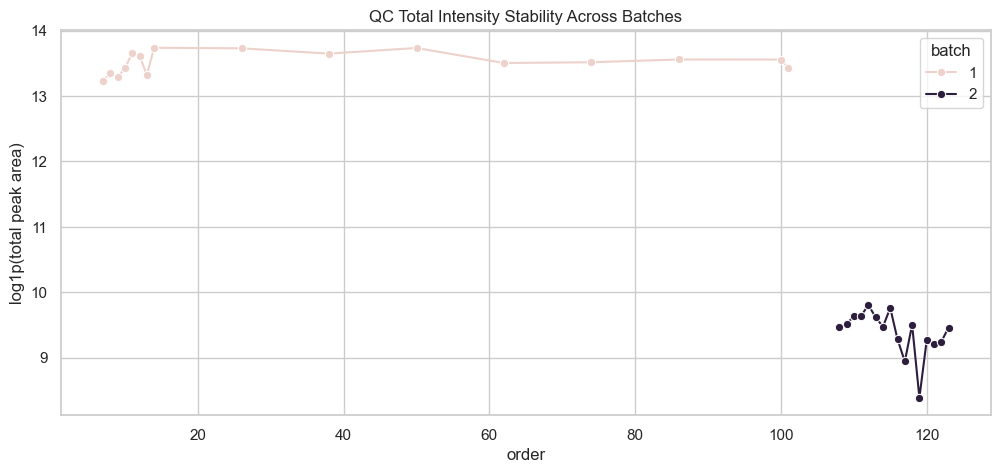

In [129]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=qc_all.sort_values('order'), x='order', y='log_total_intensity', hue='batch', marker='o')
plt.title('QC Total Intensity Stability Across Batches')
plt.ylabel('log1p(total peak area)')
plt.show()

- As said before, there is significant drop in QC intensities between batch 1 and 2. 
- In batch 1, the QC intensities stayed consistent across samples.
- In batch 2, the QC intensities seems to have much more variations, therefore noise. To verify this, we compute the coefficient of variation (CV) of QC samples in batch 1 and 2 and compare them.

In [148]:
batch2_mask = acq['batch'] == 2
batch2_acq = acq.loc[batch2_mask]
batch1_acq = acq.loc[acq['batch'] == 1]

qc_b2_samples = batch2_acq.index[batch2_acq['class'].eq('QC')]
qc_b1_samples = batch1_acq.index[batch1_acq['class'].eq('QC')]
qc_b2 = X.loc[qc_b2_samples]
qc_b1 = X.loc[qc_b1_samples]

qc_b1_cv = 100 * np.log1p(qc_b1).std(axis=0, ddof=1) / np.log1p(qc_b1).mean(axis=0).replace(0, np.nan)
qc_b2_cv = 100 * np.log1p(qc_b2).std(axis=0, ddof=1) / np.log1p(qc_b2).mean(axis=0).replace(0, np.nan)

cv_comp = pd.DataFrame({'QC_batch1_CV': qc_b1_cv, 'QC_batch2_CV': qc_b2_cv}).replace([np.inf, -np.inf], np.nan)

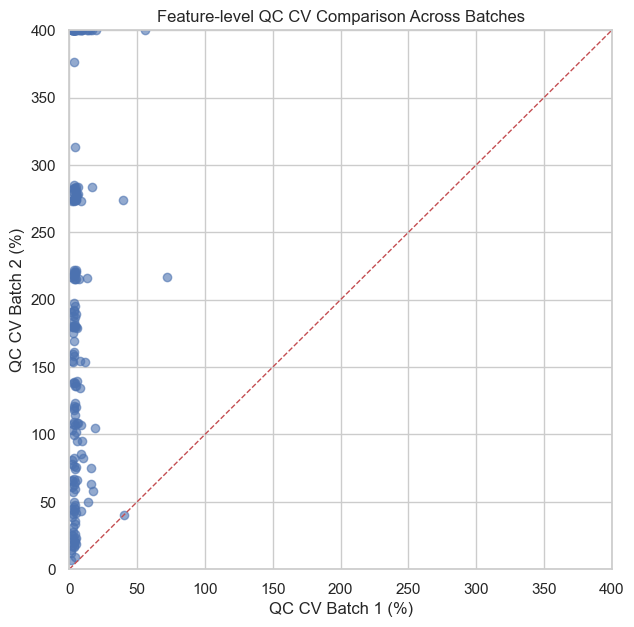

In [149]:
plt.figure(figsize=(7, 7))
plt.scatter(cv_comp['QC_batch1_CV'], cv_comp['QC_batch2_CV'], alpha=0.6)
lims = [0, np.nanpercentile(cv_comp.values, 95)]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('QC CV Batch 1 (%)')
plt.ylabel('QC CV Batch 2 (%)')
plt.title('Feature-level QC CV Comparison Across Batches')
plt.show()

In [150]:
print('QC CV batch comparison summary:')
print(cv_comp.describe())

QC CV batch comparison summary:
       QC_batch1_CV  QC_batch2_CV
count    252.000000    181.000000
mean       7.280522    191.656154
std       10.259625    130.226063
min        1.039800      7.059883
25%        3.183878     75.013713
50%        4.281344    179.878136
75%        6.876338    278.383284
max       73.446673    400.000000


- Feature-level QC CV is substantially larger in batch 2, so there is a lot more intrument noise in batch 2.

### Conclusion

The dataset appears usable for biomarker discovery in batch 1 after quality filtering/normalization. Main risks are batch effect and feature-level technical dominance for part of the panel. A robust next step is to retain features with high detection support, low QC CV, low blank signal, and favorable D-ratio before class-comparison statistics.